### Detecção de Câncer de Pulmão em Imagens Médicas com Deep Learning


Objetivo: Treinar/Testar um modelo de Deep Learning com arquitetura de Rede Neural Convolucional.


### Carregando os Pacotes

In [ ]:
# Antes de carregar os pacotes, execute no terminal o comando os comandos:
# pip install numpy==1.24.3
# pip install tensorflow==2.13.1
# pip install imutils==0.5.4
# pip install -r requirements.txt

In [1]:
# Imports
import os
import sys
import cv2
import random
import tensorflow
import keras
import itertools
import matplotlib as m
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Flatten, Dense
from tensorflow.keras.preprocessing.image import img_to_array, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import imutils
from imutils import paths
import argparse
from tensorflow.keras.models import load_model





2026-04-12 20:42:34.412004: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-12 20:42:34.426710: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-12 20:42:34.585884: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-12 20:42:34.586541: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-12 20:42:35.345813: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

### Carregando as Imagens

In [2]:
# Diretório das imagens em disco
imagens_treino = "./dados/treino/"

In [ ]:
imagens = []
labels = []

In [ ]:
# Lista as imagens e faz o shuffle
imagePaths = sorted(list(paths.list_images(imagens_treino)))
random.seed(42)
random.shuffle(imagePaths)

In [ ]:
# Loop pelas imagens e leitura com OpenCV
for imagePath in imagePaths:
    
    # Leitura da imagem
    image = cv2.imread(imagePath)
    
    # Redimensionamento para 40x40 pixels
    image = cv2.resize(image, (40,40))
    
    image = img_to_array(image)
    
    imagens.append(image)
    
    # Extrai o label
    label = imagePath[-7:-4]
    
    # Define o valor 0 ou 1 para o label
    if "pos" in imagePath:
        label = 1
    else:
        label = 0
        
    labels.append(label)

In [46]:
# Normalização das imagens
imagens = np.array(imagens, dtype = "float") / 255.0

In [ ]:
labels = np.array(labels)

In [ ]:
labels

array([0, 0, 1, ..., 0, 0, 1])

Vamos visualizar algumas imagens.

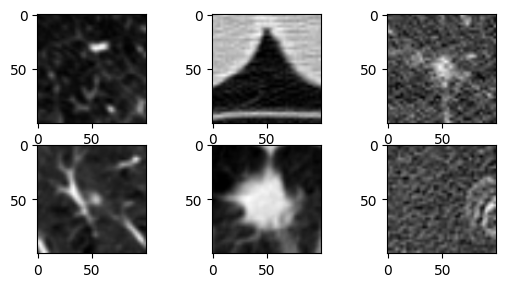

In [49]:
# Plot das imagens
for i, images in enumerate(imagePaths[:6]):
    img = cv2.imread(images)
    img = cv2.resize(img, (100, 100))
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.grid(False)
plt.show()

### Pré-Processamento das Imagens

In [145]:
# Divisão em treino/teste com proporção 75/25
(x_treino, x_teste, y_treino, y_teste) = train_test_split(imagens, labels, test_size = 0.25, random_state = 42,stratify=labels)

In [146]:
# Shape
# Formato = número de imagens x altura x largura x número de canais de cores
x_treino.shape

(2206, 40, 40, 3)

In [147]:
# Shape
# Formato = número de imagens x altura x largura x número de canais de cores
x_teste.shape

(736, 40, 40, 3)

In [148]:
y_treino.shape
y_teste.shape

(736,)

Por fim, criamos o gerador de imagens para o treinamento.

In [149]:
# Gerador de imagens
aug = ImageDataGenerator(rotation_range = 30, 
                         width_shift_range = 0.1, 
                         height_shift_range = 0.1, 
                         shear_range = 0.2, 
                         zoom_range = 0.2, 
                         horizontal_flip = True, 
                         fill_mode = "nearest")

### Construção do Modelo

In [150]:
# Hiperparâmetros

# Número de épocas
epochs = 50

# Taxa de aprendizagem
lr = 1e-3

# Tamanho do batch
batch_size = 32

In [ ]:
# Modelo CNN
class ModeloCNN:
    
    @staticmethod
    def build(width, height, depth):
        
        # Cria a sequência de camadas
        model = Sequential()
        
        # Shape de entrada
        inputShape = (height, width, depth)

        # Formato das imagens
        if K.image_data_format() == "channels_first":
            inputShape = (depth, height, width)
        
        # Primeira camada convolucional com ativação Relu e MaxPooling
        model.add(Conv2D(20, (5, 5), padding = "same", input_shape = inputShape))
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size = (2, 2), strides = (2, 2)))

        # Segunda camada convolucional com ativação Relu e MaxPooling
        model.add(Conv2D(50, (5, 5), padding = "same"))
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size = (2, 2), strides = (2, 2)))

        # Primeirca camada totalmente conectada com ativação Relu
        model.add(Flatten())
        model.add(Dense(500))
        model.add(Activation("relu"))

        # Camada de saída com classificação sigmoid
        model.add(Dense(1))
        model.add(Activation("sigmoid"))

        return model

In [ ]:
# Cria o modelo
modelo_cnn = ModeloCNN.build(width = 40, height = 40, depth = 3)

In [153]:
# Cria o otimizador com algoritmo Adam
otimizador = Adam(learning_rate= lr)

In [154]:
# Compila o modelo com o otimizador, função de custo e métricas
modelo_cnn.compile(optimizer = otimizador, loss = "binary_crossentropy", metrics = ["accuracy"])

In [155]:
# Sumário do modelo
modelo_cnn.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_22 (Conv2D)          (None, 40, 40, 20)        1520      
                                                                 
 activation_44 (Activation)  (None, 40, 40, 20)        0         
                                                                 
 max_pooling2d_22 (MaxPooli  (None, 20, 20, 20)        0         
 ng2D)                                                           
                                                                 
 conv2d_23 (Conv2D)          (None, 20, 20, 50)        25050     
                                                                 
 activation_45 (Activation)  (None, 20, 20, 50)        0         
                                                                 
 max_pooling2d_23 (MaxPooli  (None, 10, 10, 50)        0         
 ng2D)                                               

### Treinamento

In [ ]:
# Treina o modelo

print("\nIniciando o Treinamento...\n")

hist = modelo_cnn.fit(aug.flow(x_treino, y_treino, batch_size = batch_size), 
                                validation_data = (x_teste, y_teste), 
                                steps_per_epoch = len(x_treino) // batch_size, 
                                epochs = epochs, 
                                verbose = 1)

print("\nTreinamento Concluído.\n")


Iniciando o Treinamento...

Epoch 1/50
68/68 [==============================] - 3s 34ms/step - loss: 0.5070 - accuracy: 0.7557 - val_loss: 0.4051 - val_accuracy: 0.8166
Epoch 2/50
68/68 [==============================] - 2s 31ms/step - loss: 0.3758 - accuracy: 0.8422 - val_loss: 0.2983 - val_accuracy: 0.8859
Epoch 3/50
68/68 [==============================] - 2s 30ms/step - loss: 0.3110 - accuracy: 0.8809 - val_loss: 0.2873 - val_accuracy: 0.8886
Epoch 4/50
68/68 [==============================] - 2s 31ms/step - loss: 0.2725 - accuracy: 0.8956 - val_loss: 0.2774 - val_accuracy: 0.9035
Epoch 5/50
68/68 [==============================] - 2s 29ms/step - loss: 0.2673 - accuracy: 0.9002 - val_loss: 0.2850 - val_accuracy: 0.8750
Epoch 6/50
68/68 [==============================] - 2s 31ms/step - loss: 0.2350 - accuracy: 0.9131 - val_loss: 0.2423 - val_accuracy: 0.9076
Epoch 7/50
68/68 [==============================] - 2s 32ms/step - loss: 0.2202 - accuracy: 0.9190 - val_loss: 0.2450 - val_a

### Avaliando o Modelo

In [157]:
# Calculamos a performance do modelo com dados de teste
score = modelo_cnn.evaluate(x_teste, y_teste, verbose = 1)


23/23 [==============================] - 0s 5ms/step - loss: 0.1549 - accuracy: 0.9497


In [158]:
print("Acurácia do Modelo em Teste: %0.2f" % score[1])

Acurácia do Modelo em Teste: 0.95


### Relatório de Classificação

In [ ]:
pred_probs = modelo_cnn.predict(x_teste)

print(pred_probs.shape)  # tem que ser (736, 1)

predY = (pred_probs > 0.5).astype(int).reshape(-1)

predY = predY.reshape(-1)
y_teste = y_teste.reshape(-1)
print(classification_report(predY, y_teste))

23/23 [==============================] - 0s 5ms/step
(736, 1)
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       369
           1       0.95      0.95      0.95       367

    accuracy                           0.95       736
   macro avg       0.95      0.95      0.95       736
weighted avg       0.95      0.95      0.95       736



In [198]:
# Salva o modelo 
modelName = "./modelo/modelo_cnn.model"
modelo_cnn.save(modelName)

INFO:tensorflow:Assets written to: ./modelo/modelo_cnn.model/assets


INFO:tensorflow:Assets written to: ./modelo/modelo_cnn.model/assets


### Testar o modelo

In [256]:
# Define o local da imagem (outras imagens estão disponíveis para teste)
image = "./dados/teste/imagem4_no_cancer.png"

In [257]:
# Define o local do modelo
model = "./modelo/modelo_cnn.model"

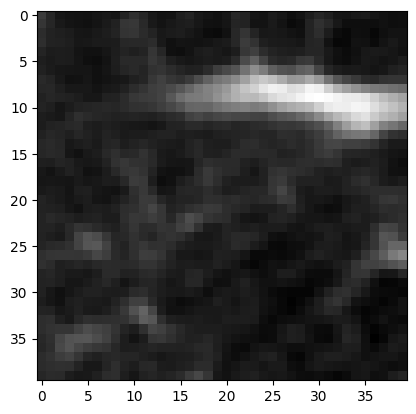

In [258]:
# Carrega a imagem
image = cv2.imread(image)
orig = image.copy()
plt.imshow(image)
plt.show()

In [259]:
# Pré-processamento da imagem
image = cv2.resize(image, (40, 40))
image = image.astype("float") / 255.0
image = img_to_array(image)
image = np.expand_dims(image, axis = 0)

In [260]:

# Carrega o modelo treinado
model = load_model(model)

In [268]:
# Fazemos a previsão (probabilidade)
score = model.predict(image)[0][0]

# Definimos o threshold (0.5 padrão)
if score < 0.5:
    label = "Sem Cancer"
else:
    label = "Cancer"

1/1 [==============================] - 0s 13ms/step


In [269]:

# Nível de confiança (%)
confianca = score * 100 if label == "Cancer" else (1 - score) * 100

print("Nível de confiança = {:.2f}%".format(confianca))

# Redimensiona imagem de saída
output = imutils.resize(orig, width=400)

# Define threshold de exibição
if confianca > 95:
    out = "{}: {:.2f}%".format(label, confianca)
    color = (0, 255, 0)  # verde
else:
    out = "Not detected"
    color = (255, 0, 0)  # vermelho

# Escreve texto na imagem
cv2.putText(output, out, (10, 25),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

Nível de confiança = 98.92%


array([[[59, 59, 59],
        [59, 59, 59],
        [59, 59, 59],
        ...,
        [15, 15, 15],
        [15, 15, 15],
        [15, 15, 15]],

       [[59, 59, 59],
        [59, 59, 59],
        [59, 59, 59],
        ...,
        [15, 15, 15],
        [15, 15, 15],
        [15, 15, 15]],

       [[59, 59, 59],
        [59, 59, 59],
        [59, 59, 59],
        ...,
        [15, 15, 15],
        [15, 15, 15],
        [15, 15, 15]],

       ...,

       [[38, 38, 38],
        [38, 38, 38],
        [38, 38, 38],
        ...,
        [36, 36, 36],
        [36, 36, 36],
        [36, 36, 36]],

       [[38, 38, 38],
        [38, 38, 38],
        [38, 38, 38],
        ...,
        [36, 36, 36],
        [36, 36, 36],
        [36, 36, 36]],

       [[38, 38, 38],
        [38, 38, 38],
        [38, 38, 38],
        ...,
        [36, 36, 36],
        [36, 36, 36],
        [36, 36, 36]]], dtype=uint8)

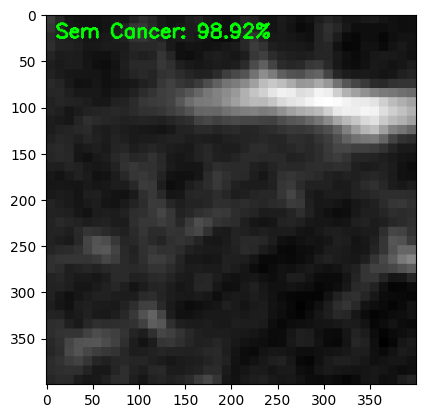

In [270]:
plt.imshow(output)
plt.show()

# Fim